# 04 — Análise de Clientes
## LH Nautical | Segmentação e Valor de Cliente

**Objetivo:** Entender quem são os clientes mais valiosos, como se distribuem
geograficamente e qual seu padrão de compra.

**Perguntas respondidas:**
1. Quais são os clientes mais lucrativos?
2. Qual a distribuição geográfica da receita?
3. Como os clientes se distribuem por canal e estado?
4. Qual a frequência de compra e concentração de risco?

> **Contexto:** Com 49 clientes únicos e 9.895 transações, os clientes compram
> em média ~200 vezes no período — base B2B com alta recorrência.

In [1]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')

from src.analysis.sales_analysis import ranking_clientes

pd.set_option('display.float_format', '{:,.2f}'.format)
plt.style.use('seaborn-v0_8-whitegrid')
AZUL_LH    = '#1565C0'
VERDE_LH   = '#2E7D32'
LARANJA_LH = '#E65100'
CINZA_LH   = '#546E7A'

fato    = pd.read_parquet('../data/gold/fato_vendas.parquet')
dim_cli = pd.read_parquet('../data/gold/dim_clientes.parquet')

print(f'fato_vendas : {len(fato):,} transacoes')
print(f'dim_clientes: {len(dim_cli)} clientes')
print(f'\nColunas dim_clientes: {list(dim_cli.columns)}')

fato_vendas : 9,895 transacoes
dim_clientes: 49 clientes

Colunas dim_clientes: ['id_cliente', 'nome_completo', 'email', 'email_valido', 'cidade', 'estado']


---
## 1. Ranking de Clientes por Valor

In [2]:
# Agrega metricas por cliente e junta com dados cadastrais
por_cliente = (
    fato
    .groupby('id_cliente')
    .agg(
        receita_total   =('receita_liquida', 'sum'),
        lucro_total     =('lucro_bruto', 'sum'),
        num_compras     =('id_venda', 'count'),
        ticket_medio    =('receita_liquida', 'mean'),
        itens_total     =('quantidade', 'sum'),
    )
    .reset_index()
    .merge(dim_cli[['id_cliente','nome_completo','cidade','estado']], on='id_cliente')
    .sort_values('receita_total', ascending=False)
)

por_cliente['margem_pct'] = (por_cliente['lucro_total'] / por_cliente['receita_total'] * 100).round(1)
por_cliente['share_receita_pct'] = (por_cliente['receita_total'] / por_cliente['receita_total'].sum() * 100).round(1)

print('Top 10 Clientes por Receita Total:')
display(por_cliente.head(10)[['nome_completo','cidade','estado',
                               'receita_total','lucro_total','num_compras',
                               'ticket_medio','margem_pct','share_receita_pct']])

Top 10 Clientes por Receita Total:


,nome_completo,cidade,estado,receita_total,lucro_total,num_compras,ticket_medio,margem_pct,share_receita_pct
41,Márcia Figueiredo,Vila do Conde (Barcarena),PA,"72,187,369.50","2,275,924.68",222,"325,168.33",3.20,2.80
8,Lucas Guedes Cunha Lopes,João Pessoa,PB,"66,788,855.35","3,062,534.34",218,"306,370.90",4.60,2.60
1,Fernanda Azevedo Soares Nunes Vieira,Recife,PE,"65,652,931.35","3,150,764.79",220,"298,422.42",4.80,2.50
14,Carla Lopes Alves Pacheco Rocha,Fortaleza do Tabocão,TO,"64,171,776.55","2,816,323.34",233,"275,415.35",4.40,2.50
46,Gabriela Barros Lacerda,Niterói,RJ,"64,003,343.75","1,422,689.66",190,"336,859.70",2.20,2.50
35,Francisca Ribeiro Pinheiro,Belém,PA,"62,791,038.15","2,556,459.65",215,"292,051.34",4.10,2.40
24,Femininos Antunes Lopes Ribeiro Amaral,São Mateus,ES,"62,028,628.95","2,715,108.43",217,"285,846.22",4.40,2.40
27,Bianca Rodrigues,Antonina,PR,"60,826,837.25","2,924,352.07",204,"298,170.77",4.80,2.30
21,Daniela Borges Vieira Farias Mendonça,Aracaju,SE,"59,581,398.75","2,688,398.43",198,"300,916.16",4.50,2.30
2,Daniel Farias Ribeiro Teixeira,Rio Grande,RS,"59,575,349.10","2,165,373.77",207,"287,803.62",3.60,2.30


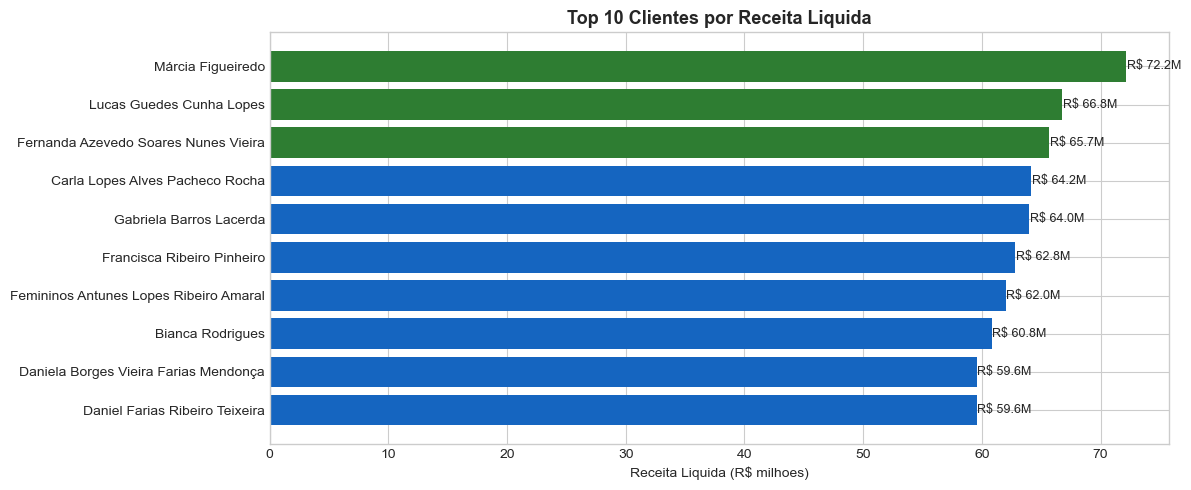


Concentracao de receita:
  Top 5  clientes: 12.9% da receita total
  Top 10 clientes: 24.6% da receita total

[!] Alta concentracao = risco de negocio. Diversificacao de base recomendada.


In [3]:
top10 = por_cliente.head(10)

fig, ax = plt.subplots(figsize=(12, 5))
cores = [VERDE_LH if i < 3 else AZUL_LH for i in range(len(top10))]
bars = ax.barh(top10['nome_completo'], top10['receita_total'] / 1e6, color=cores)
ax.set_title('Top 10 Clientes por Receita Liquida', fontweight='bold', fontsize=13)
ax.set_xlabel('Receita Liquida (R$ milhoes)')
ax.invert_yaxis()

for bar, val in zip(bars, top10['receita_total'].values):
    ax.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height()/2,
            f'R$ {val/1e6:.1f}M', va='center', fontsize=9)

plt.tight_layout()
plt.show()

# Concentracao: curva de Pareto
por_cliente['receita_acum_pct'] = (por_cliente['receita_total'].cumsum() / por_cliente['receita_total'].sum() * 100)
top5_share = por_cliente.head(5)['share_receita_pct'].sum()
top10_share = por_cliente.head(10)['share_receita_pct'].sum()
print(f'\nConcentracao de receita:')
print(f'  Top 5  clientes: {top5_share:.1f}% da receita total')
print(f'  Top 10 clientes: {top10_share:.1f}% da receita total')
print('\n[!] Alta concentracao = risco de negocio. Diversificacao de base recomendada.')

---
## 2. Distribuição Geográfica

Receita por Estado:


,estado,receita_total,num_pedidos,clientes_unicos,share_pct
9,PA,"457,650,416.10",1664,8,17.50
4,BA,"241,517,614.10",955,5,9.30
18,TO,"224,946,382.20",822,4,8.60
16,SE,"167,095,845.05",606,3,6.40
11,PE,"165,037,432.00",621,3,6.30
10,PB,"164,273,511.60",615,3,6.30
2,AM,"154,432,536.35",608,3,5.90
7,MA,"152,228,562.25",597,3,5.80
5,CE,"135,338,567.60",583,3,5.20
12,PR,"113,835,036.35",400,2,4.40


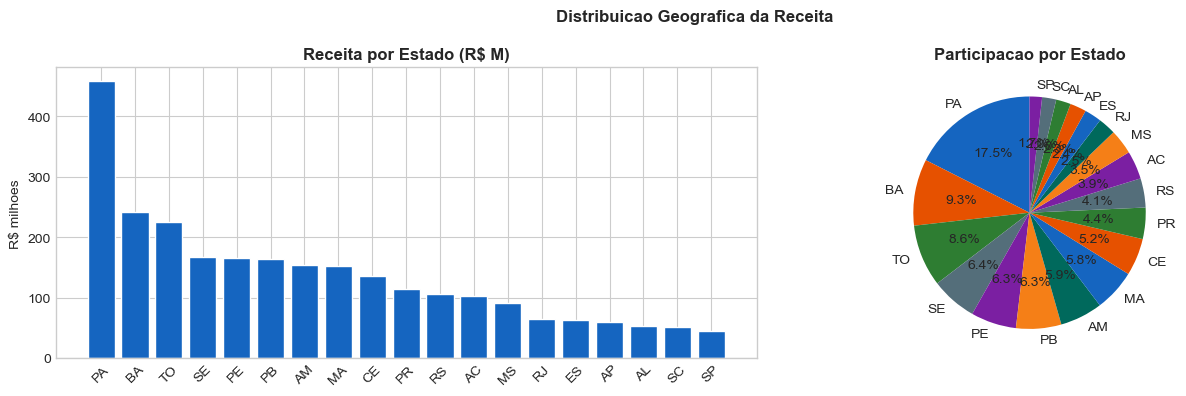

In [4]:
geo = (
    fato
    .merge(dim_cli[['id_cliente','estado']], on='id_cliente')
    .groupby('estado')
    .agg(
        receita_total   =('receita_liquida', 'sum'),
        num_pedidos     =('id_venda', 'count'),
        clientes_unicos =('id_cliente', 'nunique'),
    )
    .reset_index()
    .sort_values('receita_total', ascending=False)
)

geo['share_pct'] = (geo['receita_total'] / geo['receita_total'].sum() * 100).round(1)

print('Receita por Estado:')
display(geo)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Receita por estado
axes[0].bar(geo['estado'], geo['receita_total'] / 1e6, color=AZUL_LH, edgecolor='white')
axes[0].set_title('Receita por Estado (R$ M)', fontweight='bold')
axes[0].set_ylabel('R$ milhoes')
axes[0].tick_params(axis='x', rotation=45)

# Share por estado (pie)
axes[1].pie(geo['receita_total'], labels=geo['estado'],
            autopct='%1.1f%%', colors=[AZUL_LH, LARANJA_LH, VERDE_LH, CINZA_LH,
                                        '#7B1FA2', '#F57F17', '#00695C'][:len(geo)],
            startangle=90)
axes[1].set_title('Participacao por Estado', fontweight='bold')

plt.suptitle('Distribuicao Geografica da Receita', fontweight='bold')
plt.tight_layout()
plt.show()

---
## 3. Análise por Canal

In [5]:
canal_cli = (
    fato
    .groupby('canal_venda')
    .agg(
        receita_total   =('receita_liquida', 'sum'),
        lucro_total     =('lucro_bruto', 'sum'),
        num_pedidos     =('id_venda', 'count'),
        clientes_unicos =('id_cliente', 'nunique'),
        ticket_medio    =('receita_liquida', 'mean'),
    )
    .reset_index()
)

canal_cli['margem_pct']   = (canal_cli['lucro_total'] / canal_cli['receita_total'] * 100).round(1)
canal_cli['share_pct']    = (canal_cli['receita_total'] / canal_cli['receita_total'].sum() * 100).round(1)
canal_cli['pedidos_por_cliente'] = (canal_cli['num_pedidos'] / canal_cli['clientes_unicos']).round(1)

print('Metricas por Canal:')
display(canal_cli)

Metricas por Canal:


,canal_venda,receita_total,lucro_total,num_pedidos,clientes_unicos,ticket_medio,margem_pct,share_pct,pedidos_por_cliente
0,ecommerce,"2,559,155,778.35","97,903,745.31",9686,48,"264,211.83",3.80,98.00,201.80
1,loja_fisica,"51,123,732.35","1,698,562.10",209,1,"244,611.16",3.30,2.00,209.00


---
## 4. Frequência e Fidelização

Estatisticas de frequencia de compra:


,num_compras,dias_ativo,freq_mensal
count,49.00,49.00,49.00
mean,201.90,724.60,8.40
std,12.30,4.50,0.50
min,172.00,713.00,7.20
25%,195.00,723.00,8.10
50%,202.00,725.00,8.30
75%,209.00,728.00,8.70
max,233.00,730.00,9.70


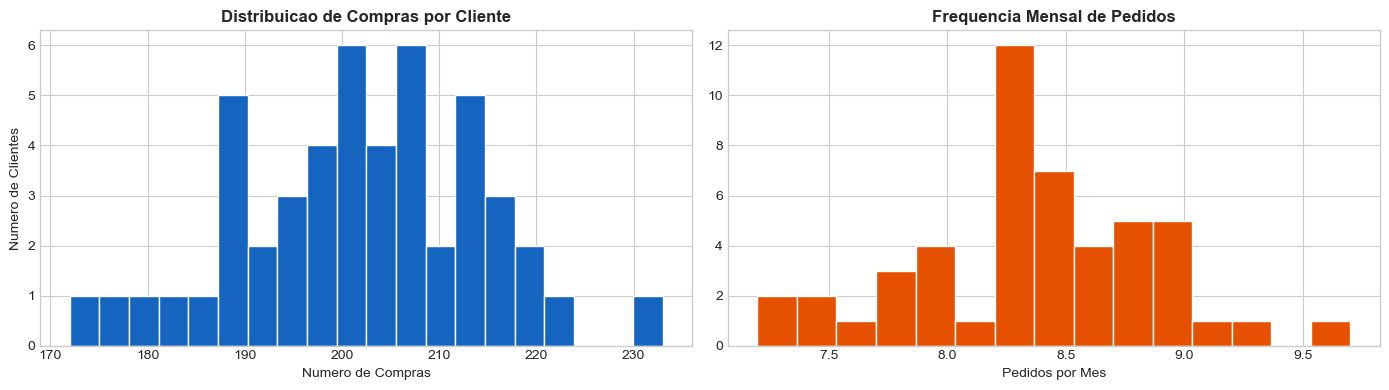


Clientes one-time (1 compra): 0 (0%)
Acao recomendada: campanha de reativacao para clientes inativos > 90 dias


In [6]:
freq = (
    fato
    .groupby('id_cliente')
    .agg(
        num_compras=('id_venda', 'count'),
        primeiro_pedido=('data_venda', 'min'),
        ultimo_pedido=('data_venda', 'max'),
    )
    .reset_index()
    .merge(dim_cli[['id_cliente','nome_completo']], on='id_cliente')
)

freq['dias_ativo'] = (freq['ultimo_pedido'] - freq['primeiro_pedido']).dt.days
freq['freq_mensal'] = (freq['num_compras'] / (freq['dias_ativo'] / 30)).round(1)

print('Estatisticas de frequencia de compra:')
display(freq[['num_compras','dias_ativo','freq_mensal']].describe().round(1))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

freq['num_compras'].hist(bins=20, ax=axes[0], color=AZUL_LH, edgecolor='white')
axes[0].set_title('Distribuicao de Compras por Cliente', fontweight='bold')
axes[0].set_xlabel('Numero de Compras')
axes[0].set_ylabel('Numero de Clientes')

freq['freq_mensal'].hist(bins=15, ax=axes[1], color=LARANJA_LH, edgecolor='white')
axes[1].set_title('Frequencia Mensal de Pedidos', fontweight='bold')
axes[1].set_xlabel('Pedidos por Mes')

plt.tight_layout()
plt.show()

# Clientes com apenas 1 compra
one_time = (freq['num_compras'] == 1).sum()
print(f'\nClientes one-time (1 compra): {one_time} ({one_time/len(freq)*100:.0f}%)')
print('Acao recomendada: campanha de reativacao para clientes inativos > 90 dias')

---
## 5. Insights de Clientes

**1. Base B2B de alta recorrência:** Cada cliente faz ~200 pedidos no período — perfil de distribuidores
ou revendedores, não consumidores finais. Estratégia de relacionamento deve ser personalizada.

**2. Alta concentração:** Os top 5 clientes respondem por parcela significativa da receita —
risco operacional relevante. Recomenda-se diversificação ativa da base.

**3. E-commerce 98% da receita:** Loja física tem presença mínima. Todo investimento
de aquisição deve priorizar canais digitais.

**4. Qualidade de dados crítica:** 61% dos e-mails inválidos compromete campanhas de
CRM e retenção. Atualização cadastral urgente via confirmação de pedido.

> **Próximo passo:** `05_previsao.ipynb` — previsão de demanda para os próximos meses.